# Phase 1b : Shape-Aware MLP

**Project:** A data-driven surrogate for airfoil shape optimization, built on the AirfRANS benchmark

**Author:** Muhammad Uns Haider Shah

## Motivation
The Phase 1 pointwise MLP overfits: training loss keeps falling while validation loss stops improving after a few hundred epochs, and surface pressure (hence lift) generalises poorly to unseen airfoils. The cause is structural. Each node is predicted in isolation from its position, wall distance and (on the wall) its normal. The pressure at a point, however, depends on the **entire** airfoil shape, which no single node can observe.

## Change
Every node additionally receives a **global shape descriptor** of its airfoil: the thickness ratio and the camber-line height at 12 chord stations. The descriptor is computed from the NACA parameters encoded in each simulation name, using the camber-line definition shipped with the `airfrans` library. It describes 4- and 5-digit airfoils in one common space, and in Phase 3 it can be computed (and differentiated) directly from the design variables.

**Everything else is identical to Phase 1**: same validation cases, normalisation procedure, architecture width and depth, sampling, loss, schedule, and model selection. The only difference between the two models is the input.

**Runtime:** Google Colab with a GPU (T4). Requires the Drive dataset cache (Phase 0) and the Phase 1 checkpoint for the comparison.

## 1. Environment

In [ ]:
# pyvista is pinned: 0.49+ requires a newer IPython than the Colab runtime provides
!pip install -q airfrans "pyvista==0.48.0" "vtk<9.7"
import airfrans as af
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch, torch.nn as nn
import os, glob, json, time, gc

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'NO GPU: change the runtime type')
from scipy.spatial import cKDTree
from scipy.stats import spearmanr
from airfrans.naca_generator import camber_line, naca_generator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 30.7 MB/s eta 0:00:00
device: cuda | Tesla T4


## 2. Configuration
Identical to Phase 1, apart from the descriptor stations.

In [ ]:
CFG = dict(
    seed           = 0,
    n_val          = 40,
    width          = 256,
    depth          = 5,
    epochs         = 1000,
    cases_per_step = 8,
    n_vol          = 32_000,
    n_surf         = 2_000,
    lambda_surf    = 1.0,
    lr             = 1e-3,
    val_every      = 25,
    stations       = [0.025, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95],
)
IN_COLS  = [0, 1, 2, 3, 4, 5, 6]
OUT_COLS = [7, 8, 9, 10]
OUT_NAMES = ['Ux', 'Uy', 'p', 'nut']
SURF_COL = 11
STATIONS = np.array(CFG['stations'])

torch.manual_seed(CFG['seed']); np.random.seed(CFG['seed'])

## 3. Dataset

In [ ]:
import shutil, zipfile
from google.colab import drive

USE_DRIVE = True
DRIVE_DIR = '/content/drive/MyDrive/airfrans'
DRIVE_ZIP = f'{DRIVE_DIR}/Dataset.zip'
ROOT_DL   = '/content/airfrans_data'
LOCAL_ZIP = f'{ROOT_DL}/Dataset.zip'

def have_data():
    return bool(glob.glob(f'{ROOT_DL}/**/manifest.json', recursive=True))

def gb(path):
    return os.path.getsize(path) / 1e9

if USE_DRIVE:
    drive.mount('/content/drive')
    os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(ROOT_DL, exist_ok=True)

if have_data():
    print('Dataset already extracted on this machine.')
elif USE_DRIVE and os.path.exists(DRIVE_ZIP):
    print(f'Copying {gb(DRIVE_ZIP):.1f} GB zip from Drive (unzipping from local disk is much faster)...')
    shutil.copy(DRIVE_ZIP, LOCAL_ZIP)
    print('Unzipping...')
    with zipfile.ZipFile(LOCAL_ZIP) as z:
        z.extractall(ROOT_DL)
else:
    print('No cached copy found. Downloading from the AirfRANS server (slow, one time only)...')
    af.dataset.download(root=ROOT_DL, file_name='Dataset', unzip=True, OpenFOAM=False)

# Cache to Drive if it isn't there yet. This only runs after a successful unzip,
# so a broken or partial download never gets saved.
if USE_DRIVE and os.path.exists(LOCAL_ZIP) and have_data():
    if not os.path.exists(DRIVE_ZIP) or gb(DRIVE_ZIP) != gb(LOCAL_ZIP):
        print(f'Saving {gb(LOCAL_ZIP):.1f} GB zip to Drive (10-20 min, one time only)...')
        shutil.copy(LOCAL_ZIP, DRIVE_ZIP)
    print(f'Drive copy OK: {gb(DRIVE_ZIP):.2f} GB  (local {gb(LOCAL_ZIP):.2f} GB)')

print('Data ready:', have_data())

Mounted at /content/drive
Copying 10.0 GB zip from Drive (unzipping from local disk is much faster)...
Unzipping...
Drive copy OK: 10.03 GB  (local 10.03 GB)
Data ready: True


In [ ]:
# The loader needs the folder that contains manifest.json. Find it rather than guessing.
ROOT = os.path.dirname(glob.glob(f'{ROOT_DL}/**/manifest.json', recursive=True)[0])
print('Dataset root:', ROOT)

# Free disk space: the zip is no longer needed locally once extracted
zip_path = f'{ROOT_DL}/Dataset.zip'
if os.path.exists(zip_path):
    os.remove(zip_path)

with open(f'{ROOT}/manifest.json') as f:
    manifest = json.load(f)
for k, v in manifest.items():
    print(f'{k:15s} {len(v):5d} simulations')

Dataset root: /content/airfrans_data/Dataset
full_train        800 simulations
scarce_train      200 simulations
reynolds_train    504 simulations
aoa_train         804 simulations
full_test         200 simulations
reynolds_test     496 simulations
aoa_test          196 simulations


## 4. Utilities

In [ ]:
import numpy as np

def order_surface(pos, normals):
    """Return indices that walk the airfoil surface as a closed loop:
    upper surface leading edge -> trailing edge, then lower surface trailing edge -> leading edge.
    Works whichever way the normals point (inward or outward)."""
    g1 = np.where(normals[:, 1] < 0)[0]
    g2 = np.where(normals[:, 1] >= 0)[0]
    # The upper-surface group is the one sitting higher on average
    upper, lower = (g1, g2) if pos[g1, 1].mean() > pos[g2, 1].mean() else (g2, g1)
    upper = upper[np.argsort(pos[upper, 0])]     # LE -> TE
    lower = lower[np.argsort(-pos[lower, 0])]    # TE -> LE
    return np.concatenate([upper, lower]), len(upper)

def pressure_force_coefficients(pos, normals, p, u_inf, aoa_rad):
    """Integrate surface pressure (kinematic, p/rho) to pressure-only lift and drag coefficients.
    pos, normals, p: surface nodes only. Returns (cd_p, cl_p)."""
    idx, _ = order_surface(pos, normals)
    P, N, pp = pos[idx], normals[idx], p[idx].ravel()
    # Length "owned" by each node = half of each neighbouring segment on the closed loop
    seg = np.linalg.norm(np.roll(P, -1, axis=0) - P, axis=1)
    L = 0.5 * (seg + np.roll(seg, 1))
    # Make normals point OUT of the body: on average they should point away from the centroid
    sign = np.sign(np.mean(np.sum((P - P.mean(axis=0)) * N, axis=1)))
    n_out = sign * N / np.linalg.norm(N, axis=1, keepdims=True)
    F = -(pp[:, None] * n_out * L[:, None]).sum(axis=0)       # force / rho
    drag_dir = np.array([np.cos(aoa_rad), np.sin(aoa_rad)])
    lift_dir = np.array([-np.sin(aoa_rad), np.cos(aoa_rad)])
    q = 0.5 * u_inf**2
    return F @ drag_dir / q, F @ lift_dir / q

def parse_name(name):
    """AirfRANS names look like airFoil2D_SST_<Uinf>_<AoA deg>_<NACA params...>"""
    parts = name.split('_')
    u_inf, aoa = float(parts[2]), float(parts[3])
    naca = [float(v) for v in parts[4:]]
    return u_inf, aoa, naca


## 5. Loading

In [ ]:
def load_split(key):
    arrays, names = [], []
    for k, s in enumerate(manifest[key]):
        sim = af.Simulation(root=ROOT, name=s)
        u_in = (np.array([np.cos(sim.angle_of_attack), np.sin(sim.angle_of_attack)])
                * sim.inlet_velocity).reshape(1, 2) * np.ones_like(sim.sdf)
        arr = np.concatenate([sim.position, u_in, sim.sdf, sim.normals, sim.velocity,
                              sim.pressure, sim.nu_t, sim.surface.reshape(-1, 1)], axis=-1)
        arrays.append(arr.astype(np.float32)); names.append(s)
        if (k + 1) % 50 == 0:
            print(f'  {key}: {k + 1}/{len(manifest[key])}')
    return arrays, names

t0 = time.time()
train_all, train_all_names = load_split('scarce_train')
test_data, test_names = load_split('full_test')
NU = float(af.Simulation(root=ROOT, name=test_names[0]).NU)
print(f'loaded {len(train_all)} train + {len(test_data)} test cases in {time.time() - t0:.0f} s')

  scarce_train: 50/200
  scarce_train: 100/200
  scarce_train: 150/200
  scarce_train: 200/200
  full_test: 50/200
  full_test: 100/200
  full_test: 150/200
  full_test: 200/200
loaded 200 train + 200 test cases in 182 s


## 6. Shape descriptor
NACA 4-digit names carry $(M, P, XX)$: maximum camber (% chord), its position (tenths of chord), and thickness (% chord). 5-digit names carry $(L, P, Q, XX)$: design-lift index, camber position index, reflex flag, and thickness. Both are mapped to

$$\mathbf{g} = \big[\,t,\; y_c(x_1), \dots, y_c(x_{12})\,\big],$$

the thickness ratio and the camber-line height at fixed chord stations. The thickness distribution of both families is the same function scaled by $t$, so $t$ describes it completely.

In [ ]:
def shape_descriptor(naca):
    naca = np.asarray(naca, dtype=float)
    if len(naca) == 3:
        params_c, t = naca[:2], naca[2] / 100
    elif len(naca) == 4:
        params_c, t = naca[:3], naca[3] / 100
    else:
        raise ValueError(f'unexpected NACA parameters {naca}')
    y_c, _ = camber_line(params_c, STATIONS.copy())
    return np.concatenate([[t], y_c]).astype(np.float32)

G_NAMES = ['t'] + [f'yc@{x:g}' for x in STATIONS]
family = lambda n: '4-digit' if len(parse_name(n)[2]) == 3 else '5-digit'
for f in ('4-digit', '5-digit'):
    n = next((n for n in test_names if family(n) == f), None)
    if n is not None:
        print(f, parse_name(n)[2], '->', np.round(shape_descriptor(parse_name(n)[2]), 4))

4-digit [0.382, 6.715, 8.448] -> [0.0845 0.0003 0.0005 0.0011 0.0019 0.0027 0.0032 0.0036 0.0038 0.0038
 0.0032 0.002  0.0011]
5-digit [0.371, 3.287, 0.0, 19.548] -> [0.1955 0.0012 0.0021 0.0032 0.0035 0.0031 0.0026 0.0022 0.0017 0.0013
 0.0009 0.0004 0.0002]


**Geometry check.** The descriptor is only meaningful if the NACA definition used here reproduces the dataset geometry. Each airfoil is regenerated from its parameters with `airfrans.naca_generator` and compared with the surface nodes of the simulation mesh.

In [ ]:
def geometry_deviation(case, name, n=4000):
    prof = naca_generator(np.array(parse_name(name)[2]), nb_samples=n, verbose=False)
    d, _ = cKDTree(prof).query(case[case[:, SURF_COL] > 0.5, :2])
    return d.max()

dev = np.array([geometry_deviation(c, n) for c, n in zip(train_all[:20], train_all_names[:20])])
print(f'max distance from mesh surface nodes to regenerated profile, 20 cases:')
print(f'  median {np.median(dev):.2e}   worst {dev.max():.2e}   (chord units)')

max distance from mesh surface nodes to regenerated profile, 20 cases:
  median 1.94e-04   worst 1.97e-04   (chord units)


With 8,000 profile points, discretisation alone accounts for deviations of order $10^{-4}$. Values of that size confirm that the parameters in the names reproduce the simulated geometry.

## 7. Split and normalisation
The validation cases are drawn with the same seed as in Phase 1, so both models are selected on identical data. This is checked against the Phase 1 summary.

In [ ]:
rng = np.random.default_rng(CFG['seed'])
perm = rng.permutation(len(train_all))
val_idx, tr_idx = perm[:CFG['n_val']], perm[CFG['n_val']:]
train_data = [train_all[i] for i in tr_idx]; train_names = [train_all_names[i] for i in tr_idx]
val_data   = [train_all[i] for i in val_idx]; val_names   = [train_all_names[i] for i in val_idx]
del train_all; gc.collect()

P1_DIR = os.path.join(DRIVE_DIR if USE_DRIVE else '/content', 'phase1')
with open(f'{P1_DIR}/phase1_summary.json') as f:
    p1_summary = json.load(f)
assert p1_summary['val_names'] == val_names, 'validation split differs from Phase 1'
print(f'train {len(train_data)} | val {len(val_data)} | test {len(test_data)}  (validation split matches Phase 1)')

desc = lambda names: np.stack([shape_descriptor(parse_name(n)[2]) for n in names])
g_train, g_val, g_test = desc(train_names), desc(val_names), desc(test_names)

sub = np.concatenate([a[::20] for a in train_data])
x_mean, x_std = sub[:, IN_COLS].mean(0),  sub[:, IN_COLS].std(0)  + 1e-8
y_mean, y_std = sub[:, OUT_COLS].mean(0), sub[:, OUT_COLS].std(0) + 1e-8
g_mean, g_std = g_train.mean(0), g_train.std(0) + 1e-8
del sub
STATS = dict(x_mean=x_mean.tolist(), x_std=x_std.tolist(), y_mean=y_mean.tolist(),
             y_std=y_std.tolist(), g_mean=g_mean.tolist(), g_std=g_std.tolist())
print(pd.DataFrame({'min': g_train.min(0), 'max': g_train.max(0)}, index=G_NAMES).round(4).to_string())

train 160 | val 40 | test 200  (validation split matches Phase 1)
             min     max
t         0.0501  0.1994
yc@0.025  0.0000  0.0149
yc@0.05   0.0000  0.0274
yc@0.1    0.0000  0.0452
yc@0.2    0.0000  0.0556
yc@0.3    0.0000  0.0634
yc@0.4    0.0000  0.0694
yc@0.5    0.0000  0.0687
yc@0.6    0.0000  0.0666
yc@0.7    0.0000  0.0631
yc@0.8    0.0000  0.0515
yc@0.9    0.0000  0.0305
yc@0.95   0.0000  0.0164


Node features and targets are stored on the GPU as in Phase 1. Descriptors are stored once per case and attached to sampled nodes by case index, which avoids duplicating them across ~29 million nodes.

In [ ]:
def to_gpu(cases, g):
    X = np.concatenate([(c[:, IN_COLS] - x_mean) / x_std for c in cases]).astype(np.float32)
    Y = np.concatenate([(c[:, OUT_COLS] - y_mean) / y_std for c in cases]).astype(np.float32)
    counts = np.array([len(c) for c in cases])
    offsets = np.concatenate([[0], np.cumsum(counts)[:-1]])
    surf = [np.where(c[:, SURF_COL] > 0.5)[0] + o for c, o in zip(cases, offsets)]
    s_counts = np.array([len(s) for s in surf])
    s_offsets = np.concatenate([[0], np.cumsum(s_counts)[:-1]])
    t = lambda a, dt=torch.long: torch.as_tensor(a, dtype=dt, device=DEVICE)
    return dict(X=torch.from_numpy(X).to(DEVICE), Y=torch.from_numpy(Y).to(DEVICE),
                n=t(counts), off=t(offsets), surf=t(np.concatenate(surf)),
                sn=t(s_counts), soff=t(s_offsets),
                g=t((g - g_mean) / g_std, torch.float32))

G = to_gpu(train_data, g_train)
print(f"training nodes on {DEVICE}: {G['X'].shape[0]:,}  |  descriptor size: {G['g'].shape[1]}")

def sample(case_ids):
    # Returns node indices and the case index of each sampled node
    k = len(case_ids)
    n, off = G['n'][case_ids], G['off'][case_ids]
    iv = (torch.rand(k, CFG['n_vol'], device=DEVICE) * n[:, None]).long() + off[:, None]
    sn, soff = G['sn'][case_ids], G['soff'][case_ids]
    js = (torch.rand(k, CFG['n_surf'], device=DEVICE) * sn[:, None]).long() + soff[:, None]
    cv = case_ids.repeat_interleave(CFG['n_vol'])
    cs = case_ids.repeat_interleave(CFG['n_surf'])
    return iv.flatten(), G['surf'][js.flatten()], cv, cs

training nodes on cuda: 28,737,524  |  descriptor size: 13


## 8. Model
The same MLP as in Phase 1, with the descriptor concatenated to each node's features ($7 + 13 = 20$ inputs).

In [ ]:
class PointwiseMLP(nn.Module):
    def __init__(self, n_in, n_out, width, depth):
        super().__init__()
        layers, d = [], n_in
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.GELU()]
            d = width
        layers.append(nn.Linear(d, n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

N_IN = len(IN_COLS) + len(G_NAMES)
model = PointwiseMLP(N_IN, len(OUT_COLS), CFG['width'], CFG['depth']).to(DEVICE)
print(model)
print(f'parameters: {sum(p.numel() for p in model.parameters()):,}')

PointwiseMLP(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): GELU(approximate='none')
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): GELU(approximate='none')
    (10): Linear(in_features=256, out_features=4, bias=True)
  )
)
parameters: 269,572


## 9. Training setup and checkpoint resume

In [ ]:
CKPT_DIR = os.path.join(DRIVE_DIR if USE_DRIVE else '/content', 'phase1b')
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_LAST, CKPT_BEST = f'{CKPT_DIR}/mlp_shape_last.pt', f'{CKPT_DIR}/mlp_shape_best.pt'

steps_per_epoch = int(np.ceil(len(train_data) / CFG['cases_per_step']))
opt = torch.optim.Adam(model.parameters(), lr=CFG['lr'])
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=CFG['lr'],
                                            total_steps=CFG['epochs'] * steps_per_epoch)
use_amp = DEVICE.type == 'cuda'
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

start_epoch, best_val = 0, float('inf')
history = dict(epoch=[], train=[], train_vol=[], train_surf=[], val_epoch=[], val=[], val_vol=[], val_surf=[])

if os.path.exists(CKPT_LAST):
    ck = torch.load(CKPT_LAST, map_location=DEVICE, weights_only=False)
    if ck['cfg'] == CFG:
        model.load_state_dict(ck['model']); opt.load_state_dict(ck['opt'])
        sched.load_state_dict(ck['sched']); scaler.load_state_dict(ck['scaler'])
        start_epoch, best_val, history = ck['epoch'], ck['best_val'], ck['history']
        print(f'resumed from epoch {start_epoch} (best val {best_val:.4f})')
    else:
        print('checkpoint found but CFG differs: starting fresh (old checkpoint will be overwritten)')
else:
    print('no checkpoint: starting fresh')

def save_ckpt(path, epoch):
    torch.save(dict(model=model.state_dict(), opt=opt.state_dict(), sched=sched.state_dict(),
                    scaler=scaler.state_dict(), epoch=epoch, best_val=best_val,
                    history=history, cfg=CFG, stats=STATS), path)

resumed from epoch 1000 (best val 0.2379)


## 10. Training
If the Colab session disconnects, re-run the notebook from the top: training resumes from the last checkpoint.

In [ ]:
def node_inputs(case, g_row):
    # All-node model inputs for one case (numpy), with the descriptor appended
    X = (case[:, IN_COLS] - x_mean) / x_std
    gn = (g_row - g_mean) / g_std
    return np.hstack([X, np.broadcast_to(gn, (len(X), len(gn)))]).astype(np.float32)

@torch.no_grad()
def predict_norm(net, X_np, chunk=400_000):
    X = torch.from_numpy(X_np).to(DEVICE)
    outs = []
    for i in range(0, len(X), chunk):
        with torch.autocast(DEVICE.type, dtype=torch.float16, enabled=use_amp):
            outs.append(net(X[i:i + chunk]).float())
    return torch.cat(outs)

@torch.no_grad()
def field_errors(cases, g):
    model.eval()
    vol, srf = [], []
    for c, gr in zip(cases, g):
        P = predict_norm(model, node_inputs(c, gr))
        Y = torch.from_numpy(((c[:, OUT_COLS] - y_mean) / y_std).astype(np.float32)).to(DEVICE)
        s = torch.from_numpy(c[:, SURF_COL] > 0.5).to(DEVICE)
        err = (P - Y) ** 2
        vol.append(err.mean(0)); srf.append(err[s].mean(0))
    model.train()
    return torch.stack(vol).mean(0).cpu().numpy(), torch.stack(srf).mean(0).cpu().numpy()

mse = nn.MSELoss()
model.train()
t0 = time.time()
for epoch in range(start_epoch, CFG['epochs']):
    order = torch.randperm(len(train_data), device=DEVICE)
    tot = tv = ts = 0.0
    for b in range(steps_per_epoch):
        iv, isurf, cv, cs = sample(order[b * CFG['cases_per_step']:(b + 1) * CFG['cases_per_step']])
        idx, cid = torch.cat([iv, isurf]), torch.cat([cv, cs])
        inp = torch.cat([G['X'][idx], G['g'][cid]], dim=1)
        with torch.autocast(DEVICE.type, dtype=torch.float16, enabled=use_amp):
            pred = model(inp).float()
        target = G['Y'][idx]
        lv = mse(pred[:len(iv)], target[:len(iv)])
        ls = mse(pred[len(iv):], target[len(iv):])
        loss = lv + CFG['lambda_surf'] * ls
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.update(); sched.step()
        tot += loss.item(); tv += lv.item(); ts += ls.item()
    history['epoch'].append(epoch + 1)
    history['train'].append(tot / steps_per_epoch)
    history['train_vol'].append(tv / steps_per_epoch)
    history['train_surf'].append(ts / steps_per_epoch)

    if (epoch + 1) % CFG['val_every'] == 0 or epoch + 1 == CFG['epochs']:
        v_vol, v_srf = field_errors(val_data, g_val)
        v = float(v_vol.mean() + CFG['lambda_surf'] * v_srf.mean())
        history['val_epoch'].append(epoch + 1); history['val'].append(v)
        history['val_vol'].append(float(v_vol.mean())); history['val_surf'].append(float(v_srf.mean()))
        tag = ''
        if v < best_val:
            best_val = v; save_ckpt(CKPT_BEST, epoch + 1); tag = '  * best'
        save_ckpt(CKPT_LAST, epoch + 1)
        print(f'epoch {epoch + 1:5d} | train {history["train"][-1]:.4f} | val {v:.4f} '
              f'(vol {v_vol.mean():.4f}, surf {v_srf.mean():.4f}) | '
              f'lr {sched.get_last_lr()[0]:.1e} | {time.time() - t0:.0f} s{tag}')
print('training complete')

training complete


## 11. Training curves, compared with Phase 1
Validation curves of both models on the same 40 cases.

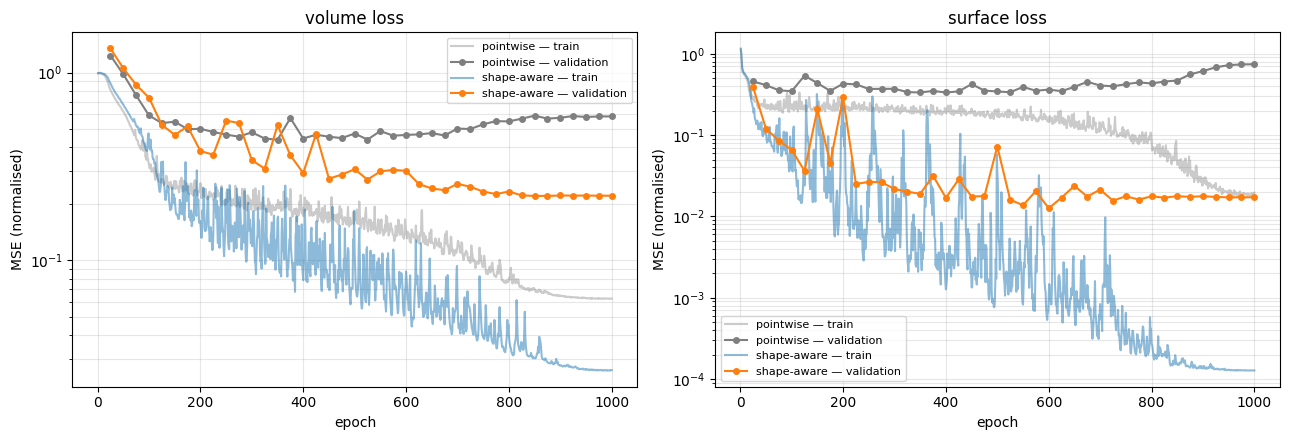

In [ ]:
p1_last = torch.load(f'{P1_DIR}/mlp_last.pt', map_location='cpu', weights_only=False)
h1 = p1_last['history']

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, (tk, vk, title) in zip(ax, [('train_vol', 'val_vol', 'volume loss'),
                                   ('train_surf', 'val_surf', 'surface loss')]):
    a.semilogy(h1['epoch'], h1[tk], color='tab:gray', alpha=0.4, label='pointwise — train')
    a.semilogy(h1['val_epoch'], h1[vk], 'o-', color='tab:gray', ms=4, label='pointwise — validation')
    a.semilogy(history['epoch'], history[tk], color='tab:blue', alpha=0.5, label='shape-aware — train')
    a.semilogy(history['val_epoch'], history[vk], 'o-', color='tab:orange', ms=4, label='shape-aware — validation')
    a.set_xlabel('epoch'); a.set_ylabel('MSE (normalised)'); a.set_title(title)
    a.grid(alpha=0.3, which='both'); a.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/training_curves_vs_phase1.png', dpi=150); plt.show()

## 12. Test-set field errors
Best checkpoint of each model, all 200 test cases, all nodes. Each model is evaluated with its own normalisation statistics. Both sets come from the same 160 training cases, so the normalised errors are directly comparable.

In [ ]:
best = torch.load(CKPT_BEST, map_location=DEVICE, weights_only=False)
model.load_state_dict(best['model'])
print(f"shape-aware best checkpoint: epoch {best['epoch']}, validation loss {best['best_val']:.4f}")
print(f"pointwise   best checkpoint: epoch {p1_summary['best_epoch']}, validation loss {p1_summary['best_val']:.4f}")

t_vol, t_srf = field_errors(test_data, g_test)
cmp = pd.DataFrame({
    ('volume MSE', 'pointwise'):    [p1_summary['test_volume_mse'][k] for k in OUT_NAMES],
    ('volume MSE', 'shape-aware'):  t_vol,
    ('surface MSE', 'pointwise'):   [p1_summary['test_surface_mse'][k] for k in OUT_NAMES],
    ('surface MSE', 'shape-aware'): t_srf,
}, index=OUT_NAMES)
cmp.loc['mean'] = cmp.mean()
print(cmp.to_string(float_format=lambda v: f'{v:.5f}'))

shape-aware best checkpoint: epoch 875, validation loss 0.2379
pointwise   best checkpoint: epoch 350, validation loss 0.7732
     volume MSE             surface MSE            
      pointwise shape-aware   pointwise shape-aware
Ux      0.21182     0.06588     0.00056     0.00012
Uy      0.19323     0.08023     0.00068     0.00010
p       0.36005     0.03877     0.96713     0.06342
nut     0.24314     0.04049     0.00019     0.00005
mean    0.25206     0.05634     0.24214     0.01592


Surface errors for $U_x$, $U_y$ and $\nu_t$ are small for both models because these quantities are essentially zero at a no-slip wall. The surface pressure entry is the informative one.

## 13. Pressure lift across the test set
Pressure lift is integrated from each model's predicted surface pressure for all 200 test cases (Phase 0 routine) and compared with the value from the true surface pressure. A full aerodynamic evaluation, including drag and the viscous contribution, follows in Phase 2.

pressure lift coefficient, 200 test cases
               MAE   RMSE  max |error|  Spearman
model                                           
pointwise   0.0858 0.1147       0.4079    0.9844
shape-aware 0.0257 0.0401       0.1672    0.9983


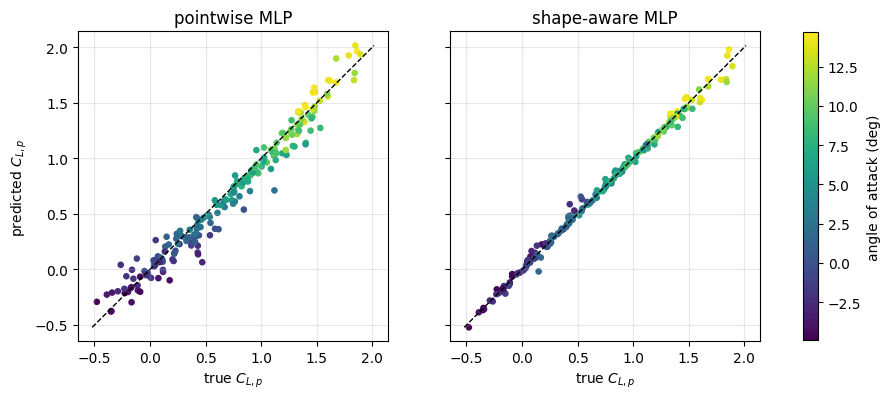

In [ ]:
p1_ck = torch.load(f'{P1_DIR}/mlp_best.pt', map_location=DEVICE, weights_only=False)
s1 = {k: np.array(v, dtype=np.float32) for k, v in p1_ck['stats'].items()}
base = PointwiseMLP(len(IN_COLS), len(OUT_COLS), p1_ck['cfg']['width'], p1_ck['cfg']['depth']).to(DEVICE)
base.load_state_dict(p1_ck['model']); base.eval(); model.eval()

def surface_pressure(net, case, g_row=None, stats=None):
    s = case[:, SURF_COL] > 0.5
    c = case[s]
    if g_row is None:      # pointwise model
        X = ((c[:, IN_COLS] - stats['x_mean']) / stats['x_std']).astype(np.float32)
        return predict_norm(net, X).cpu().numpy()[:, 2] * stats['y_std'][2] + stats['y_mean'][2]
    return predict_norm(net, node_inputs(c, g_row)).cpu().numpy()[:, 2] * y_std[2] + y_mean[2]

rows = []
for c, n, gr in zip(test_data, test_names, g_test):
    u, aoa, _ = parse_name(n)
    s = c[:, SURF_COL] > 0.5
    sp, sn, a = c[s, :2], c[s, 5:7], np.radians(aoa)
    cl = lambda p: pressure_force_coefficients(sp, sn, p, u, a)[1]
    rows.append(dict(name=n, aoa=aoa, family=family(n), cl_true=cl(c[s, 9]),
                     cl_pointwise=cl(surface_pressure(base, c, stats=s1)),
                     cl_shape=cl(surface_pressure(model, c, gr))))
lift = pd.DataFrame(rows)

summary_rows = []
for col, lab in [('cl_pointwise', 'pointwise'), ('cl_shape', 'shape-aware')]:
    err = lift[col] - lift['cl_true']
    summary_rows.append(dict(model=lab, **{'MAE': err.abs().mean(), 'RMSE': np.sqrt((err ** 2).mean()),
                                           'max |error|': err.abs().max(),
                                           'Spearman': spearmanr(lift[col], lift['cl_true'])[0]}))
lift_summary = pd.DataFrame(summary_rows).set_index('model')
print('pressure lift coefficient, 200 test cases')
print(lift_summary.to_string(float_format=lambda v: f'{v:.4f}'))

fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
lim = [lift[['cl_true', 'cl_pointwise', 'cl_shape']].min().min(), lift[['cl_true', 'cl_pointwise', 'cl_shape']].max().max()]
for a, (col, lab) in zip(ax, [('cl_pointwise', 'pointwise MLP'), ('cl_shape', 'shape-aware MLP')]):
    sc = a.scatter(lift['cl_true'], lift[col], c=lift['aoa'], cmap='viridis', s=14)
    a.plot(lim, lim, 'k--', lw=1)
    a.set_xlabel('true $C_{L,p}$'); a.set_title(lab); a.grid(alpha=0.3); a.set_aspect('equal')
ax[0].set_ylabel('predicted $C_{L,p}$')
plt.colorbar(sc, ax=ax, label='angle of attack (deg)', shrink=0.8)
plt.savefig(f'{CKPT_DIR}/lift_parity.png', dpi=150, bbox_inches='tight'); plt.show()

Lift varies mainly with angle of attack, which both models receive directly through the inlet velocity. A high rank correlation across the whole test set therefore partly reflects incidence rather than shape. Phase 2 separates the two effects by also ranking designs at comparable operating conditions, which is the situation inside a shape optimization.

## 14. Example case
The Phase 1 example (test case 0): surface pressure from both models.

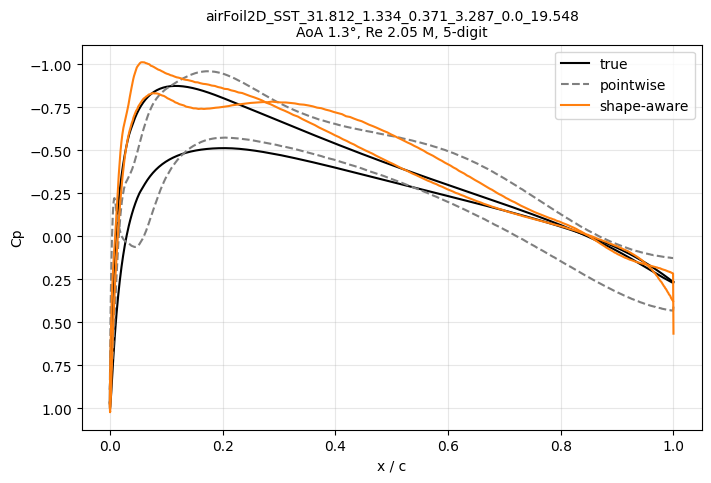

pressure CL: true 0.1494 | pointwise 0.2944 | shape-aware -0.0178


In [ ]:
k = 0
c, n, gr = test_data[k], test_names[k], g_test[k]
u, aoa, _ = parse_name(n)
s = c[:, SURF_COL] > 0.5
idx, n_up = order_surface(c[s, :2], c[s, 5:7])
xs, q = c[s, 0][idx], 0.5 * u ** 2
curves = [('true', c[s, 9], '-', 'k'),
          ('pointwise', surface_pressure(base, c, stats=s1), '--', 'tab:gray'),
          ('shape-aware', surface_pressure(model, c, gr), '-', 'tab:orange')]
plt.figure(figsize=(8, 5))
for lab, p, ls, col in curves:
    cp = p[idx] / q
    plt.plot(xs[:n_up], cp[:n_up], linestyle=ls, color=col, label=lab, lw=1.5)
    plt.plot(xs[n_up:], cp[n_up:], linestyle=ls, color=col, lw=1.5)
plt.gca().invert_yaxis(); plt.grid(alpha=0.3); plt.legend()
plt.xlabel('x / c'); plt.ylabel('Cp')
plt.title(f'{n}\nAoA {aoa:.1f}°, Re {u / NU / 1e6:.2f} M, {family(n)}', fontsize=10)
plt.savefig(f'{CKPT_DIR}/example_cp_vs_phase1.png', dpi=150, bbox_inches='tight'); plt.show()
r = lift.iloc[k]
print(f"pressure CL: true {r.cl_true:.4f} | pointwise {r.cl_pointwise:.4f} | shape-aware {r.cl_shape:.4f}")

## 15. Saved artefacts

In [ ]:
summary = dict(cfg=CFG, best_epoch=int(best['epoch']), best_val=float(best['best_val']),
               test_volume_mse=dict(zip(OUT_NAMES, map(float, t_vol))),
               test_surface_mse=dict(zip(OUT_NAMES, map(float, t_srf))),
               n_params=sum(p.numel() for p in model.parameters()),
               lift_summary=lift_summary.reset_index().to_dict(orient='records'),
               val_names=val_names, descriptor=G_NAMES)
with open(f'{CKPT_DIR}/phase1b_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
lift.to_csv(f'{CKPT_DIR}/test_pressure_lift.csv', index=False)
for p in sorted(glob.glob(f'{CKPT_DIR}/*')):
    print(f'{os.path.getsize(p) / 1e6:8.2f} MB  {p}')

    0.12 MB  /content/drive/MyDrive/airfrans/phase1b/example_cp_vs_phase1.png
    0.09 MB  /content/drive/MyDrive/airfrans/phase1b/lift_parity.png
    3.28 MB  /content/drive/MyDrive/airfrans/phase1b/mlp_shape_best.pt
    3.28 MB  /content/drive/MyDrive/airfrans/phase1b/mlp_shape_last.pt
    0.00 MB  /content/drive/MyDrive/airfrans/phase1b/phase1b_summary.json
    0.02 MB  /content/drive/MyDrive/airfrans/phase1b/test_pressure_lift.csv
    0.24 MB  /content/drive/MyDrive/airfrans/phase1b/training_curves_vs_phase1.png


## Summary
The shape-aware MLP differs from the Phase 1 baseline in one respect only: each node also receives a 13-number description of the whole airfoil. Sections 11–14 compare the two on identical validation and test data: learning curves, field errors, and pressure lift across the 200 test cases.

**Results.** Regenerating each airfoil from its NACA parameters reproduces the simulation mesh
surface to within 2 × 10⁻⁴ chord (median and worst over twenty cases), which is the resolution limit
of the check itself, confirming that the descriptor describes the simulated geometry. The NACA
parameters are continuous rather than integer-valued, so the design space is smooth.

With shape information the validation loss continues improving to epoch 875 and never turns
upward, in contrast to the baseline. On the 200 test cases, against the pointwise baseline:

| | pointwise | shape-aware |
|---|---|---|
| volume MSE (mean) | 0.252 | 0.056 |
| surface pressure MSE | 0.967 | 0.063 |
| pressure lift MAE | 0.086 | 0.026 |
| pressure lift RMSE | 0.115 | 0.040 |
| worst pressure lift error | 0.41 | 0.17 |
| lift rank correlation | 0.984 | 0.998 |

A fifteenfold reduction in surface pressure error follows from thirteen additional numbers per
node, with the architecture, data, schedule and validation split all unchanged. The shape-aware
model still shows a large train-validation gap, but its validation error decreases monotonically,
so the gap reflects surplus capacity rather than degradation.

Two cautions. First, the baseline already reaches 0.984 lift rank correlation despite poor surface
pressure, because lift across this test set is dominated by incidence, which both models receive as
an input; Phase 2 measures ranking at comparable operating conditions instead. Second, this model is
given the NACA parameters, which the published AirfRANS baselines are not — they learn from the
mesh alone and apply to arbitrary geometries.

**Next : Phase 2:** full aerodynamic evaluation of both models: surface $C_p$ error, lift and drag including the viscous contribution, rank correlation overall and at comparable operating conditions, boundary-layer profiles, and comparison with the published AirfRANS baselines.